In [ ]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки
from scipy import integrate

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки special
from scipy import special

# подключение программной библиотеки
from scipy.stats import norm

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения функции (12.65)
def Phi0(x, x0, Sigma, L):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения

    # вычисление значений функции (12.65)
    tmp = (x - x0) / Sigma
    z = np.exp(-(tmp**2) / 2)

    return z

In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# значения функции (12.66)
def Phi_2N_plus_ones_plus(x, x0, Sigma, L, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # N - число, определяющее число мнимых
    #     источников, равное 2*N+1

    # вычисление координаты 2*N+1-ого
    # мнимого источника, расположенного справа от
    # правой границы области рассеяния
    X_2N_plus_one_plus = (4 * N + 2) * L - x0

    # вычисление значений функции (12.66)
    tmp = (x - X_2N_plus_one_plus) / Sigma
    z = np.exp(-(tmp**2) / 2)

    return z


In [ ]:
# Ячейка № 4

# задание функции, возвращающей
# значения функции (12.67)
def Phi_2N_plus_ones_minus(x, x0, Sigma, L, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # N - число, определяющее число мнимых
    #     источников, равное 2*N+1

    # вычисление координаты 2*N+1-ого
    # мнимого источника, находящегося
    # слева от левой границы области
    # рассеяния
    X_2N_plus_one_minus = -(4 * N + 2) * L - x0

    # вычисление значений функции (12.67)
    tmp = (x - X_2N_plus_one_minus) / Sigma
    z = np.exp(-(tmp**2) / 2)

    return z

In [5]:
# Ячейка № 5

# задание функции, возвращающей
# значения функции (12.68)
def Phi_2N_plus(x, x0, Sigma, L, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # N - число, определеющее число мнимых
    #     источников, равное 2*N+1

    # вычисление координаты 2*N-ого
    # мнимого источника, расположенного справа
    # от правой границы области рассеяния,
    # в соответствие с (12.62)
    X_2N_plus = 4 * N * L + x0

    # вычисление значений функции (12.68)
    tmp = (x - X_2N_plus) / Sigma
    z = np.exp(-(tmp**2) / 2)

    return z


In [6]:
# Ячейка № 6

# задание функции, возвращающей
# значения функции (12.69)
def Phi_2N_minus(x, x0, Sigma, L, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # N - число, определяющее число мнимых
    #     источников, равное 2*N+1

    # вычисление координаты 2*N-ого
    # мнимого источника, расположенного слева
    # от левой границы области рассеяния,
    # в соответствие с (12.62)
    X_2N_minus = -4 * N * L + x0

    # вычисление значений функции (12.69)
    tmp = (x - X_2N_minus) / Sigma
    z = np.exp(-(tmp**2) / 2)

    return z


In [7]:
# Ячейка № 7

# задание функции, возвращающей значения
# функции (12.63), вычисленные
# в узлах используемой сетки
def pdf_LAD(x, x0, Sigma, L, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождющего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # N - число, определяющее число мнимых
    #     источников, равное 2*N+1

    # определение числа узлов сетки
    M = len(x)

    # инициализация массива,
    # используемого для хранения
    # значений плотности распределения
    # случайной величины с ограниченной
    # областью рассеяния
    p = np.zeros(M)

    # если используется более трех источников
    if N > 1:
        # инициализация массива,
        # используемого для хранения
        # значений плотности распределения
        # мнимых источников, ближайших к
        # правой и левой границам
        # области рассеяния, соответственно,
        # x_plus[1], x_minus[1]
        f2 = np.zeros([M, N])
        f3 = np.zeros([M, N])
        # инициализация массивов,
        # используемых для хранения
        # значений плотностей распределений
        # дополнительных мнимых источников, расположенных,
        # соответственно, справа и слева границ
        # области рассеяния в точках с координатами
        # x_plus[2], x_plus[3],..., x_plus[2*N+1]
        # x_minus[2], x_minus[3],..., x_minus[2*N+1],
        # вычисляемыми в соответствии с (12.62)
        f4 = np.zeros([M, N - 1])
        f5 = np.zeros([M, N - 1])

    # вычисление значений функции (12.65)
    F_generative = Phi0(x, x0, Sigma, L)

    # вычисление значений
    # плотности распределения
    # случайной величины
    # с ограниченной областью рассеяния (12.63)
    if N == 1:
        # вычисление значений функций (12.66), (12.67)
        x_2N_plus_ones = 2 * L - x0
        tmp = (x - x_2N_plus_ones) / Sigma
        f2 = np.exp(-(tmp**2) / 2)
        x_2N_plus_ones = -2 * L - x0
        tmp = (x - x_2N_plus_ones) / Sigma
        f3 = np.exp(-(tmp**2) / 2)

        # вычисление в каждом узле
        # используемой сетки
        # суммы функций (12.65), (12.66), (12.67)
        p = F_generative + f2 + f3
    else:
        # вычисление в каждом узле
        # используемой сетки
        # значений функций (12.66)-(12.69)
        for n in range(N):
            x_2N_plus_ones = (4 * n + 2) * L - x0
            tmp = (x - x_2N_plus_ones) / Sigma
            f2[:, n] = np.exp(-(tmp**2) / 2)
            x_2N_plus_ones = -(4 * n + 2) * L - x0
            tmp = (x - x_2N_plus_ones) / Sigma
            f3[:, n] = np.exp(-(tmp**2) / 2)
            if n > 0:
                x_2N_plus = 4 * n * L + x0
                tmp = (x - x_2N_plus) / Sigma
                f4[:, n - 1] = np.exp(-(tmp**2) / 2)
                x_2N_minus = -4 * n * L + x0
                tmp = (x - x_2N_minus) / Sigma
                f5[:, n - 1] = np.exp(-(tmp**2) / 2)
            # вычисление в каждом узле
            # используемой сетки
            # суммы функций (12.65)-(12.69)
            p = (
                F_generative
                + np.sum(f2, axis=1)
                + np.sum(f3, axis=1)
                + np.sum(f4, axis=1)
                + np.sum(f5, axis=1)
            )

    # вычисление нормировочного коэффициента в (12.63)
    d = np.trapz(p, dx=x[1] - x[0])

    # вычисление нормированной
    # плотности распределения
    # случайной величины
    # с ограниченной областью рассеяния
    p = p / d

    return p

In [8]:
# Ячейка № 8

# задание функции, возвращающей значения
# плотности распределения случайной величины
# с ограниченной областью рассеяния, вычисленные
# в узлах используемой сетки в соответствие с (12.70)


def cdf_LAD(x, x0, Sigma, L, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # L - размер области рассеяния
    # N - число, определяющее число мнимых
    #     источников, равное 2*N+1

    # определение числа узлов сетки
    M = len(x)

    # инициализация массива,
    # используемого для хранения
    # значений функции распределения
    # случайной величины с ограниченной
    # областью рассеяния
    p = np.zeros(M)

    # если используется более трех источников
    if N > 1:
        # инициализация массива,
        # используемого для хранения
        # значений плотности распределения
        # мнимых источников, ближайших к
        # правой и левой границам
        # области рассеяния, соответственно,
        # x_plus[1], x_minus[1]
        f2 = np.zeros([M, N])
        f3 = np.zeros([M, N])

        # инициализация массивов,
        # используемых для хранения
        # значений плотностей распределений
        # дополнительных мнимых источников, расположенных,
        # соответственно, справа и слева границ
        # области рассеяния в точках с координатами
        # x_plus[2], x_plus[3],..., x_plus[2*N+1]
        # x_minus[2], x_minus[3],..., x_minus[2*N+1],
        # вычисляемыми в соответствии с (12.62)
        f4 = np.zeros([M, N - 1])
        f5 = np.zeros([M, N - 1])

    # вычисление значений функции (12.65)
    F_generative = Phi0(x, x0, Sigma, L)

    if N == 1:
        # вычисление значений функций (12.66), (12.67)
        x_2N_plus_ones = 2 * L - x0
        tmp = (x - x_2N_plus_ones) / Sigma
        f2 = np.exp(-(tmp**2) / 2)
        x_2N_plus_ones = -2 * L - x0
        tmp = (x - x_2N_plus_ones) / Sigma
        f3 = np.exp(-(tmp**2) / 2)
        # вычисление в каждом узле
        # используемой сетки
        # функций (12.65), (12.66), (12.67)
        p = F_generative + f2 + f3
    else:
        # вычисление в каждом узле
        # используемой сетки
        # значений функций (12.66)-(12.69)
        for n in range(N):
            x_2N_plus_ones = (4 * n + 2) * L - x0
            tmp = (x - x_2N_plus_ones) / Sigma
            f2[:, n] = np.exp(-(tmp**2) / 2)
            x_2N_plus_ones = -(4 * n + 2) * L - x0
            tmp = (x - x_2N_plus_ones) / Sigma
            f3[:, n] = np.exp(-(tmp**2) / 2)
            if n > 0:
                x_2N_plus = 4 * n * L + x0
                tmp = (x - x_2N_plus) / Sigma
                f4[:, n - 1] = np.exp(-(tmp**2) / 2)
                x_2N_minus = -4 * n * L + x0
                tmp = (x - x_2N_minus) / Sigma
                f5[:, n - 1] = np.exp(-(tmp**2) / 2)

            # вычисление в каждом узле
            # используемой сетки
            # суммы функций (12.65)-(12.69)
            p = (
                F_generative
                + np.sum(f2, axis=1)
                + np.sum(f3, axis=1)
                + np.sum(f4, axis=1)
                + np.sum(f5, axis=1)
            )

    # вычисление значений интеграла,
    # как функции c переменным верхним
    # пределом в соответствие с (12.50)
    d = integrate.cumulative_trapezoid(
        p, dx=x[1] - x[0]
    )  # integrate.cumtrapz(p, dx = x[1] - x[0])

    # вычисление нормированной
    # на единицу функции распределения
    # случайной величины с ограниченной
    # областью рассеяния
    d = d / d[M - 2]

    return d


In [9]:
# Ячейка № 9

# задание функции, возвращающей
# значения квартиля функции распределения,
# заданной набором значений
def cdf_inv(p, F):
    # p - значение доверительной вероятности
    # F - массив, содержащий значения
    # функции распределения
    F_bool = (F < p).astype(bool)
    i = 0
    while F_bool[i]:
        i = i + 1
    z = x[i]

    return z


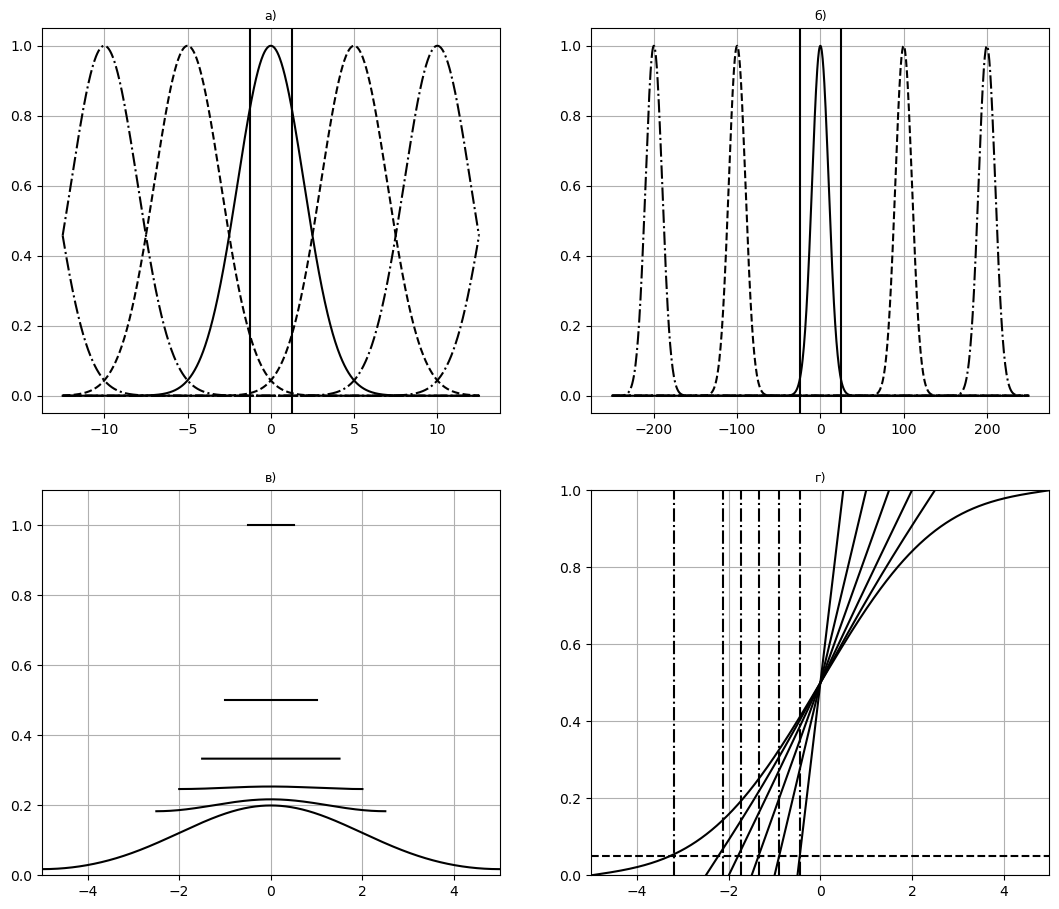

2 * L =  1.0  q =  -0.45000095000095003
2 * L =  2.0  q =  -0.8991998991998992
2 * L =  3.0  q =  -1.3319368319368319
2 * L =  4.0  q =  -1.737843737843738
2 * L =  5.0  q =  -2.115844615844616
2 * L =  10.0  q =  -3.1858481858481857


In [ ]:
# Ячейка № 10

# визуализация значений
# функций, вычисляемых в соответствие
# с (12.63) - (12.70) в узлах выбранной
# координатной сетки

# задание набора параметров функций № 1,
# вычисляемых в соответствие
# с (12.65) - (12.69) в узлах выбранной
# координатной сетки
x0 = 0
Sigma = 2
L = 2.5

# задание параметра, определяющего число
# используемых в (12.63) функций,
# число функций равняется 2*N+1
N = 2

# вычисление значений координат
# узлов сетки № 1
x = np.linspace(-5 * L, 5 * L, 1000)

# вычисление и визуализация значений
# функций с набором параметров № 1,
# вычисляемых в соответствие
# с (12.65) - (12.69) в узлах
# сетки № 1
fig = plt.figure(figsize=(13, 11))

ax = plt.subplot(2, 2, 1)
for n in range(N):
    if n == 0:
        # вычисление значений функции Phi[0]
        # вв соответствие с (12.65)
        F_generative = Phi0(x, x0, Sigma, L)

        # вычисление значений функции Phi_plus[1]
        # в соответствие с (12.66)
        Phi_ones_plus_odd = Phi_2N_plus_ones_plus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_minus[1]
        # в соответствие с (12.67)
        Phi_ones_minus_odd = Phi_2N_plus_ones_minus(x, x0, Sigma, L, n)

        # визуализация значений
        # функций Phi[0], Phi_plus[1], Phi_minus[1]
        plt.plot(x, F_generative, "-k")
        plt.plot(x, Phi_ones_plus_odd, "--k")
        plt.plot(x, Phi_ones_minus_odd, "--k")
    else:
        # вычисление значений функции Phi_plus[2*n+1]
        # в соответствие с (12.66)
        Phi_ones_plus_odd = Phi_2N_plus_ones_plus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_minus[2*n+1]
        # в соответствие с (12.67)
        Phi_ones_minus_odd = Phi_2N_plus_ones_minus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_plus[2*n]
        # в соответствие с (12.68)
        Phi_ones_plus_even = Phi_2N_plus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_minus[2*n]
        # в соответствие с (12.69)
        Phi_ones_minus_even = Phi_2N_minus(x, x0, Sigma, L, n)

        # визуализация значений
        # функций Phi_plus[2*n+1], Phi_minus[2*n+1],
        # Phi_plus[2*n], Phi_minus[2*n]
        plt.plot(x, Phi_ones_plus_odd, "-.k")
        plt.plot(x, Phi_ones_minus_odd, "-.k")
        plt.plot(x, Phi_ones_plus_even, "-.k")
        plt.plot(x, Phi_ones_minus_even, "-.k")
plt.axvline(x=-L / 2, color="black")
plt.axvline(x=L / 2, color="black")
plt.grid(True)
ax.set_title("а)", fontsize=9)

# задание набора № 2 параметров функций,
# вычисляемых в соответствие
# с (12.65) - (12.69) в узлах выбранной
# координатной сетки,
x0 = 0
Sigma = 10
L = 50

# вычисление значений координат
# узлов сетки № 2
x = np.linspace(-5 * L, 5 * L, 1000)

# вычисление и визуализация значений
# функций с набором параметров № 2,
# вычисляемых в соответствие
# с (12.65) - (12.69) в узлах сетки № 2
ax = plt.subplot(2, 2, 2)

for n in range(N):
    if n == 0:
        # вычисление значений функции Phi[0]
        # вв соответствие с (12.65)
        F_generative = Phi0(x, x0, Sigma, L)

        # вычисление значений функции Phi_plus[1]
        # в соответствие с (12.66)
        Phi_ones_plus_odd = Phi_2N_plus_ones_plus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_minus[1]
        # в соответствие с (12.67)
        Phi_ones_minus_odd = Phi_2N_plus_ones_minus(x, x0, Sigma, L, n)

        # визуализация значений
        # функций Phi[0], Phi_plus[1], Phi_minus[1]
        plt.plot(x, F_generative, "-k")
        plt.plot(x, Phi_ones_plus_odd, "--k")
        plt.plot(x, Phi_ones_minus_odd, "--k")
    else:
        # вычисление значений функции Phi_plus[2*n+1]
        # в соответствие с (12.66)
        Phi_ones_plus_odd = Phi_2N_plus_ones_plus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_minus[2*n+1]
        # в соответствие с (12.67)
        Phi_ones_minus_odd = Phi_2N_plus_ones_minus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_plus[2*n]
        # в соответствие с (12.68)
        Phi_ones_plus_even = Phi_2N_plus(x, x0, Sigma, L, n)

        # вычисление значений функции Phi_minus[2*n]
        # в соответствие с (12.69)
        Phi_ones_minus_even = Phi_2N_minus(x, x0, Sigma, L, n)

        # визуализация значений
        # функций Phi_plus[2*n+1], Phi_minus[2*n+1],
        # Phi_plus[2*n], Phi_minus[2*n]
        plt.plot(x, Phi_ones_plus_odd, "-.k")
        plt.plot(x, Phi_ones_minus_odd, "-.k")
        plt.plot(x, Phi_ones_plus_even, "-.k")
        plt.plot(x, Phi_ones_minus_even, "-.k")
plt.axvline(x=-L / 2, color="black")
plt.axvline(x=L / 2, color="black")
plt.grid(True)
ax.set_title("б)", fontsize=9)
plt.grid(True)

# задание параметров распределения
x0 = 0
Sigma = 2

# задание массива,
# содержащего значения
# области рассеяния
L = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 5])

# задание числа, определяющего
# число используемых источников
# 2*9 + 1 = 19
N = 9

# визуализация плотностей распределения
# случайной величины с двухсторонней
# ограниченной областью рассеяния
ax = plt.subplot(2, 2, 3)
for i in range(len(L)):
    x = np.linspace(-L[i], L[i], 1000)
    F_pdf = pdf_LAD(x, x0, Sigma, L[i], N)
    plt.plot(x, F_pdf, "-k")
plt.xlim(-np.max(L), np.max(L))
ax.set_title("a)", fontsize=9)
plt.ylim(0, 1.1)
ax.set_title("в)", fontsize=9)
plt.grid(True)

# визуализация функции распределения
# и квартилей функции распределения
# на уровне доверительной вероятности p = 0.05
# случайной величины с двухсторонней
# ограниченной областью рассеяния
ax = plt.subplot(2, 2, 4)
p = 0.05

F_inv = np.zeros(len(L))

for i in range(len(L)):
    x = np.linspace(-L[i], L[i], 10**6)
    F_cdf = cdf_LAD(x, x0, Sigma, 2 * L[i], N)
    F_inv[i] = cdf_inv(p, F_cdf)

for i in range(len(L)):
    x = np.linspace(-L[i], L[i], 10**6)
    F_cdf = cdf_LAD(x, x0, Sigma, L[i], N)
    plt.plot(x[0 : len(F_cdf)], F_cdf[:], color="black")
    plt.axvline(x=F_inv[i], linestyle="-.", color="black")
plt.xlim(-np.max(L), np.max(L))
plt.ylim(0, 1)
plt.axhline(y=0.05, linestyle="--", color="black")
plt.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()
for i in range(len(L)):
    print("2 * L = ", 2 * L[i], " q = ", F_inv[i])

In [ ]:
# Ячейка № 11

# задание функции, возвращающей
# значения функции (12.63)


def pdf_LAD2(x, x0, Sigma, x1, x2, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # x1 - координата левой границы
    #      области рассеяния
    # x2 - координата правой границы
    #      области рассеяния
    # N - число, определяющее число мнимых
    #     источников, равное 2*N+1

    # определение числа узлов сетки
    M = len(x)

    # вычисление длины области рассеяния
    L = (x2 - x1) / 2

    # вычисление координаты
    # средней точки области рассеяния
    Dx = (x1 + x2) / 2

    # вычисление значения координаты
    # точки, в которой находится центр
    # порождающего распределения,
    # относительно средней точки
    # области рассеяния
    X0 = x0 - Dx

    # если используется более трех источников
    if N > 1:
        # инициализация массива,
        # используемого для хранения
        # значений плотности распределения
        # мнимых источников, ближайших к
        # правой и левой границам
        # области рассеяния, соответственно,
        # x_plus[1], x_minus[1]
        f2 = np.zeros([M, N])
        f3 = np.zeros([M, N])

        # инициализация массивов,
        # используемых для хранения
        # значений плотностей распределений
        # дополнительных мнимых источников, расположенных,
        # соответственно, справа и слева границ
        # области рассеяния в точках с координатами
        # x_plus[2], x_plus[3],..., x_plus[2*N+1]
        # x_minus[2], x_minus[3],..., x_minus[2*N+1],
        # вычисляемыми в соответствии с (12.62)
        f4 = np.zeros([M, N - 1])
        f5 = np.zeros([M, N - 1])

    # вычисление значений функции (12.65)
    F_generative = Phi0(x - Dx, X0, Sigma, L)

    # вычисление значений
    # плотности распределения
    # случайной величины
    # с ограниченной областью рассеяния (12.63)
    if N == 1:
        # вычисление значений функций (12.66), (12.67)
        x_2N_plus_ones = 2 * L - X0
        tmp = (x - Dx - x_2N_plus_ones) / Sigma
        f2 = np.exp(-(tmp**2) / 2)
        x_2N_plus_ones = -2 * L - X0
        tmp = (x - Dx - x_2N_plus_ones) / Sigma
        f3 = np.exp(-(tmp**2) / 2)
        # вычисление в каждом узле
        # используемой сетки
        # суммы функций (12.65), (12.65), (12.67)
        p = F_generative + f2 + f3
    else:
        # вычисление в каждом узле
        # используемой сетки
        # значений функций (12.66)-(12.69)
        for n in range(N):
            x_2N_plus_ones = (4 * n + 2) * L - X0
            tmp = (x - Dx - x_2N_plus_ones) / Sigma
            f2[:, n] = np.exp(-(tmp**2) / 2)
            x_2N_plus_ones = -(4 * n + 2) * L - X0
            tmp = (x - Dx - x_2N_plus_ones) / Sigma
            f3[:, n] = np.exp(-(tmp**2) / 2)
            if n > 0:
                x_2N_plus = 4 * n * L + X0
                tmp = (x - Dx - x_2N_plus) / Sigma
                f4[:, n - 1] = np.exp(-(tmp**2) / 2)
                x_2N_minus = -4 * n * L + X0
                tmp = (x - Dx - x_2N_minus) / Sigma
                f5[:, n - 1] = np.exp(-(tmp**2) / 2)
            # вычисление в каждом узле
            # используемой сетки
            # суммы функций (12.65)-(12.69)
            p = (
                F_generative
                + np.sum(f2, axis=1)
                + np.sum(f3, axis=1)
                + np.sum(f4, axis=1)
                + np.sum(f5, axis=1)
            )
    p[x < x1] = 0
    p[x > x2] = 0

    # вычисление нормировочного коэффициента в (12.63)
    d = np.trapz(p, dx=x[1] - x[0])

    # вычисление нормированной
    # плотности распределения
    # случайной величины
    # с ограниченной областью рассеяния
    p = p / d

    return p

In [ ]:
# Ячейка № 12

# задание функции, возвращающей
# значения функции (12.70)
def cdf_LAD2(x, x0, Sigma, x1, x2, N):
    # x - массив, содержащий координаты
    # узлов сетки по оси OX
    # x0 - координата точки нахождения
    # центра порождающего распределения
    # Sigma - среднеквадратическое отклонение
    #         порождающего распределения
    # x1 - координата левой границы
    #      области рассеяния
    # x2 - координата правой границы
    #      области рассеяния
    # N - число, определяющее число мнимых
    #     источников, равное 2*N+1

    # определение числа узлов сетки
    M = len(x)

    # вычисление длины области рассеяния
    L = (x2 - x1) / 2

    # вычисление координаты
    # средней точки области рассеяния
    Dx = (x1 + x2) / 2

    # вычисление значения координаты
    # точки, в которой находится центр
    # порождающего распределения,
    # относительно средней точки
    # области рассеяния
    X0 = x0 - Dx

    # инициализация массива,
    # используемого для хранения
    # значений функции распределения
    # случайной величины с ограниченной
    # областью рассеяния
    p = np.zeros(M)

    # если используется более трех источников
    if N > 1:
        # инициализация массива,
        # используемого для хранения
        # значений плотности распределения
        # мнимых источников, ближайших к
        # правой и левой границам
        # области рассеяния, соответственно,
        # x_plus[1], x_minus[1]
        f2 = np.zeros([M, N])
        f3 = np.zeros([M, N])

        # инициализация массивов,
        # используемых для хранения
        # значений плотностей распределений
        # дополнительных мнимых источников, расположенных,
        # соответственно, справа и слева границ
        # области рассеяния в точках с координатами
        # x_plus[2], x_plus[3],..., x_plus[2*N+1]
        # x_minus[2], x_minus[3],..., x_minus[2*N+1],
        # вычисляемыми в соответствии с (12.62)
        f4 = np.zeros([M, N - 1])
        f5 = np.zeros([M, N - 1])

    # вычисление значений функции (12.65)
    F_generative = Phi0(x - Dx, X0, Sigma, L)

    # вычисление значений
    # плотности распределения
    # случайной величины
    # с ограниченной областью рассеяния (12.63)
    if N == 1:
        # вычисление значений функций (12.66), (12.67)
        x_2N_plus_ones = 2 * L - x0
        tmp = (x - x_2N_plus_ones) / Sigma
        f2 = np.exp(-(tmp**2) / 2)
        x_2N_plus_ones = -2 * L - x0
        tmp = (x - x_2N_plus_ones) / Sigma
        f3 = np.exp(-(tmp**2) / 2)
        p = F_generative + f2 + f3
    else:
        # вычисление в каждом узле
        # используемой сетки
        # значений функций (12.66)-(12.69)
        for n in range(N):
            x_2N_plus_ones = (4 * n + 2) * L - x0
            tmp = (x - x_2N_plus_ones) / Sigma
            f2[:, n] = np.exp(-(tmp**2) / 2)
            x_2N_plus_ones = -(4 * n + 2) * L - x0
            tmp = (x - x_2N_plus_ones) / Sigma
            f3[:, n] = np.exp(-(tmp**2) / 2)
            if n > 0:
                x_2N_plus = 4 * n * L + x0
                tmp = (x - x_2N_plus) / Sigma
                f4[:, n - 1] = np.exp(-(tmp**2) / 2)
                x_2N_minus = -4 * n * L + x0
                tmp = (x - x_2N_minus) / Sigma
                f5[:, n - 1] = np.exp(-(tmp**2) / 2)
            p = (
                F_generative
                + np.sum(f2, axis=1)
                + np.sum(f3, axis=1)
                + np.sum(f4, axis=1)
                + np.sum(f5, axis=1)
            )
    # вычисление значений интеграла,
    # как функции c переменным верхним
    # пределом в соответствие с (12.50)
    d = integrate.cumulative_trapezoid(p, dx=x[1] - x[0])

    # вычисление нормированной
    # на единицу функции распределения
    # случайной величины с ограниченной
    # областью рассеяния
    d = d / d[M - 2]
    return d

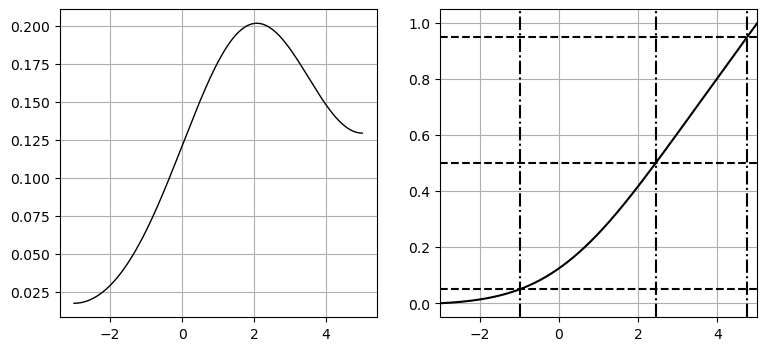

p = 0.05 q =  -0.9888598885988862
p = 0.5  q =  2.436774367743677
p = 0.95 q =  4.743837438374384


In [ ]:
# Ячейка № 13

# вычисление и визуализация
# плотности распределения,
# функции распределения,
# квартилей функции распределения
# случайной величины с ограниченной
# с двух сторон областью рассеяния, задаваемой
# координатами левой (x1) и правой (x2) границ
# области рассеяния

# задание параметров распределения
# с ограниченной областью рассеяния
x1 = -3.0
x2 = 5.0
x0 = 2
Sigma = 2

# задание координат узлов сетки по оси ОХ
x = np.linspace(x1, x2, 10**5)

# вычисление плотности вероятностей
# случайной величины с ограниченной
# областью рассеяния
F_pdf = pdf_LAD2(x, x0, Sigma, x1, x2, N)

# визуализация плотности распределения,
# функции распределения,
# квартилей функции распределения,
# случайной величины с двухсторонней
# ограниченной областью рассеяния
fig = plt.figure(figsize=(9, 4))

# визуализация плотности распределения
# случайной величины с двухсторонней
# ограниченной областью рассеяния
plt.subplot(1, 2, 1)
plt.plot(x, F_pdf, "-k", lw=1)
plt.grid(True)


# визуализация функции распределения
# и квартилей функции распределения
# на уровнях доверительной вероятности
# p = 0.05, 0.5, 0.95
plt.subplot(1, 2, 2)

# вычисление значений функции распределения
F_cdf = cdf_LAD2(x, x0, Sigma, x1, x2, N)

# вычисление значений квартилей
# функции распределения
p = 0.95
F_inv_95 = cdf_inv(p, F_cdf)
p = 0.5
F_inv_50 = cdf_inv(p, F_cdf)
p = 0.05
F_inv_5 = cdf_inv(p, F_cdf)

plt.plot(x[0 : len(F_cdf) - 1], F_cdf[0 : len(F_cdf) - 1], color="black")
plt.axvline(x=F_inv_95, linestyle="-.", color="black")
plt.axvline(x=F_inv_50, linestyle="-.", color="black")
plt.axvline(x=F_inv_5, linestyle="-.", color="black")
plt.xlim(x1, x2)
plt.axhline(y=0.05, linestyle="--", color="black")
plt.axhline(y=0.5, linestyle="--", color="black")
plt.axhline(y=0.95, linestyle="--", color="black")
plt.grid(True)
plt.show()


# отображение значений
# доверительной вероятностей
# и соответствующих значений
# квартилей распределения
print("p = 0.05 q = ", F_inv_5)
print("p = 0.5  q = ", F_inv_50)
print("p = 0.95 q = ", F_inv_95)

In [ ]:
# Модуль № 14

# вычисление и визуализация
# плотностей распределения,
# функции распределения,
# квартилей функции распределения
# усеченного нормального распределения

# задание функции, возвращающей
# плотность распределения
# усеченного нормального распределения
# в соответствие с (12.71)
def pdf_LIM(x, Mu, Sigma, a1, a2):
    # x - массив, содержащий
    #     координаты узлов сетки по оси ОХ
    # Mu - математическое ожидание
    #      порождающего нормального распределения
    # Sigma - среднеквадратическое отклонение
    #      порождающего нормального распределения
    # a1, a2 - точки усечения

    Ksi1 = (a1 - Mu) / (Sigma * np.sqrt(2))
    Ksi2 = (a2 - Mu) / (Sigma * np.sqrt(2))
    erfc_Ksi1 = special.erfc(-Ksi1)
    erfc_Ksi2 = special.erfc(-Ksi2)
    Coeff = (1 / Sigma) * 2 / (erfc_Ksi2 - erfc_Ksi1)
    z = Coeff * norm.pdf((x - Mu) / Sigma, 0, 1)

    return z


In [15]:
# Ячейка № 15

# задание функции, возвращающей
# плотность распределения
# усеченного нормального распределения
# в соответствие с (12.72)
def cdf_LIM(x, Mu, Sigma, a1, a2):
    # x - массив, содержащий
    #     координаты узлов сетки по оси ОХ
    # Mu - математическое ожидание
    #      порождающего нормального распределения
    # Sigma - среднеквадратическое отклонение
    #      порождающего нормального распределения
    # a1, a2 - точки учесения

    Ksi1 = (a1 - Mu) / (Sigma * np.sqrt(2))
    Ksi2 = (a2 - Mu) / (Sigma * np.sqrt(2))
    erfc_Ksi1 = special.erfc(-Ksi1)
    erfc_Ksi2 = special.erfc(-Ksi2)
    Coeff = 0.5 * (erfc_Ksi2 - erfc_Ksi1)
    arg_x = (x - Mu) / (Sigma * np.sqrt(2))
    erfc_x = special.erfc(-arg_x)
    z = 0.5 * (erfc_x - erfc_Ksi1) / Coeff

    return z

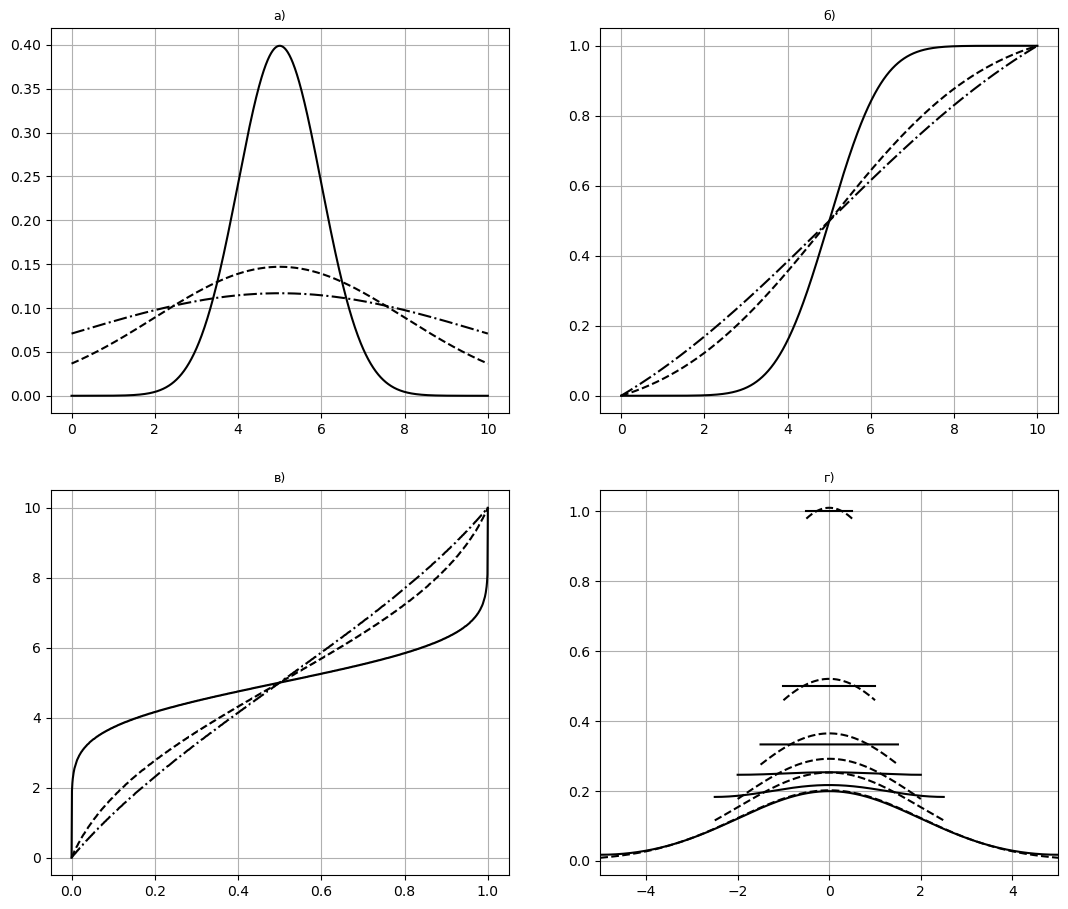

In [ ]:
# Ячейка № 16

# вычисление и визуализация
# плотностей распределения
# усеченного нормального распределения

# задание параметров усеченного
# нормального распределения
Mu = 5
a1 = 0
a2 = 10

# вычисление координат узлов сетки по оси ОХ
x = np.linspace(a1, a2, 10**3)

# визуализация
# плотностей распределения
# усеченного нормального распределения
fig = plt.figure(figsize=(13, 11))
ax = plt.subplot(2, 2, 1)
Sigma1 = 1
plt.plot(x, pdf_LIM(x, Mu, Sigma1, a1, a2), "-k")
Sigma3 = 3
plt.plot(x, pdf_LIM(x, Mu, Sigma3, a1, a2), "--k")
Sigma5 = 5
plt.plot(x, pdf_LIM(x, Mu, Sigma5, a1, a2), "-.k")
ax.grid(True)
ax.set_title("a)", fontsize=9)

# вычисление и визуализация
# функций распределения
# усеченного нормального распределения
ax = plt.subplot(2, 2, 2)
F1 = cdf_LIM(x, Mu, Sigma1, a1, a2)
plt.plot(x, F1, "-k")
F3 = cdf_LIM(x, Mu, Sigma3, a1, a2)
plt.plot(x, F3, "--k")
Sigma5 = 5
F5 = cdf_LIM(x, Mu, Sigma5, a1, a2)
plt.plot(x, F5, "-.k")
ax.grid(True)
ax.set_title("б)", fontsize=9)

# вычисление и визуализация
# зависимостей квартилей
# функций распределения
# усеченного нормального распределения
# от доверительной вероятности
ax = plt.subplot(2, 2, 3)
p = np.linspace(0, 1, 1000)
Np = len(p)
cdf_LIM_inv1 = np.zeros(Np)
for i in range(Np):
    cdf_LIM_inv1[i] = cdf_inv(p[i], F1)
plt.plot(p, cdf_LIM_inv1, "-k")

cdf_LIM_inv3 = np.zeros(Np)
for i in range(Np):
    cdf_LIM_inv3[i] = cdf_inv(p[i], F3)
plt.plot(p, cdf_LIM_inv3, "--k")

cdf_LIM_inv5 = np.zeros(len(p))
for i in range(Np):
    cdf_LIM_inv5[i] = cdf_inv(p[i], F5)
plt.plot(p, cdf_LIM_inv5, "-.k")

ax.grid(True)
ax.set_title("б)", fontsize=9)
ax.grid(True)
ax.set_title("в)", fontsize=9)

# вычисление и визуализация
# плотностей распределения
# случайной величины с ограниченной областью рассеяния
# и усеченного нормального распределения
# с соответствующими параметрами распределений
ax = plt.subplot(2, 2, 4)
x0 = 0
Sigma = 2
N = 7
for i in range(len(L)):
    x = np.linspace(-L[i], L[i], 1000)
    F_LAD = pdf_LAD2(x, x0, Sigma, -L[i], L[i], N)
    F_LIM = pdf_LIM(x, x0, Sigma, -L[i], L[i])
    plt.plot(x, F_LAD, color="black")
    plt.plot(x, F_LIM, "--k")
plt.xlim(-np.max(L), np.max(L))
ax.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()